In [39]:
import sys
import os
import time

# Get absolute path to src directory (go up from notebooks to repo root)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(repo_root, 'src')
sys.path.insert(0, src_path)

print(f"Repo root: {repo_root}")
print(f"Added to path: {src_path}")
print(f"Does it exist? {os.path.exists(src_path)}")

import numpy as np
import matplotlib.pyplot as plt
from mess.data.gp_regression import generate_gp_regression_data
from mess.problems.gp_regression import GaussianProcessRegression
from mess.algorithms.ess import ess_step
from mess.algorithms.mess import mess_step
from mess.algorithms.effective_sample_size import estimate_effective_sample_size, compute_autocorrelation, integrated_autocorrelation_time, plot_ess_histograms

Repo root: /Users/guillers/Documents/GitHub/mess
Added to path: /Users/guillers/Documents/GitHub/mess/src
Does it exist? True


In [121]:
# Problem parameters
num_data = 200
D = 5
length_scale = 1.0
noise_variance = 0.09

# Sampler parameters
n_iters = 2000
burn_in = 500

seed = 0


In [122]:
data = generate_gp_regression_data(
    num_data=num_data,
    num_dims=D,
    length_scale=length_scale,
    noise_variance=noise_variance,
    seed=seed,
)

X = data["X"]
y = data["y"]
x0 = data["f_init"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5, 200)
y shape: (200,)


In [123]:
problem = GaussianProcessRegression(
    X=X,
    y=y,
    length_scale=length_scale,
    noise_variance=noise_variance,
)
print("Initial log-likelihood:", problem.log_likelihood(x0))

Initial log-likelihood: -1794.5296365567697


In [124]:
rng_ess = np.random.default_rng(seed)

chain_ess = np.zeros((n_iters, num_data))
intervals_ess = np.zeros(n_iters, dtype=int)    
x = x0.copy()

t0 = time.time()
for t in range(n_iters):
    x, nr_intervals_ess, P1_ess = ess_step(x, problem, rng_ess)
    chain_ess[t] = x
    intervals_ess[t] = nr_intervals_ess
t1 = time.time()
ess_time = t1 - t0
print(f"ESS sampling time: {ess_time:.2f} seconds")

ESS sampling time: 0.29 seconds


In [145]:
rng_mess = np.random.default_rng(seed)

M = 100
chain_mess = np.zeros((n_iters, num_data))
intervals_mess = np.zeros(n_iters, dtype=int)
x = x0.copy()

# Uniform transition matrix
t0 = time.time()
for t in range(n_iters):
    x, nr_intervals_mess, P1_mess = mess_step(x, problem, rng_mess, M=M)
    chain_mess[t] = x
    intervals_mess[t] = nr_intervals_mess
t1 = time.time()
mess_time = t1 - t0
print(f"MESS sampling time: {mess_time:.2f} seconds")

MESS sampling time: 0.45 seconds


In [146]:
rng_mess = np.random.default_rng(seed)

chain_mess_ang = np.zeros((n_iters, num_data))
intervals_mess_ang = np.zeros(n_iters, dtype=int)
x = x0.copy()

# Transition matrix with LP, angular distance
t0 = time.time()
for t in range(n_iters):
    x, nr_intervals_mess, P1_mess = mess_step(x, problem, rng_mess, M=M, 
                                              use_lp=True, distance_metric='angular', 
                                              lam=0.05)
    chain_mess_ang[t] = x
    intervals_mess_ang[t] = nr_intervals_mess
t1 = time.time()
mess_ang_time = t1 - t0
print(f"MESS (angular) sampling time: {mess_ang_time:.2f} seconds")

MESS (angular) sampling time: 36.90 seconds


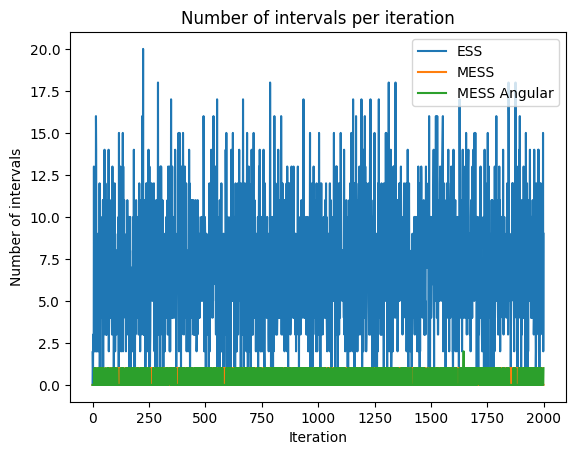

In [147]:
plt.plot(intervals_ess)
plt.plot(intervals_mess)
plt.plot(intervals_mess_ang)
plt.xlabel("Iteration")
plt.ylabel("Number of intervals")
plt.legend(["ESS", "MESS", "MESS Angular"])
plt.title("Number of intervals per iteration")
plt.show()

Text(0.5, 1.0, 'Log-likelihood trace')

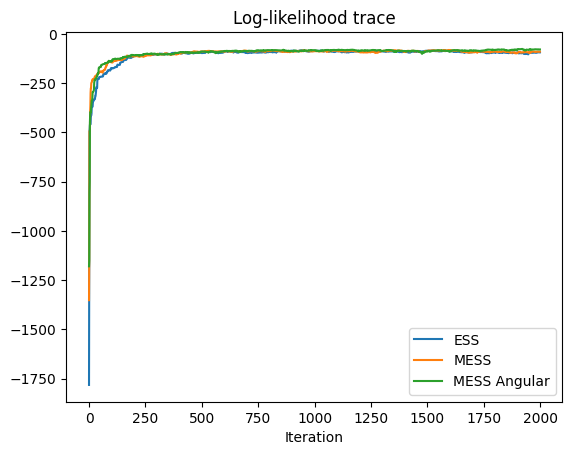

In [148]:
ll_ess = np.array([problem.log_likelihood(x) for x in chain_ess])
ll_mess = np.array([problem.log_likelihood(x) for x in chain_mess])
ll_mess_ang = np.array([problem.log_likelihood(x) for x in chain_mess_ang])

plt.plot(ll_ess[0:], label="ESS")
plt.plot(ll_mess[0:], label="MESS")
plt.plot(ll_mess_ang[0:], label="MESS Angular")
plt.xlabel("Iteration")
plt.legend()
plt.title("Log-likelihood trace")


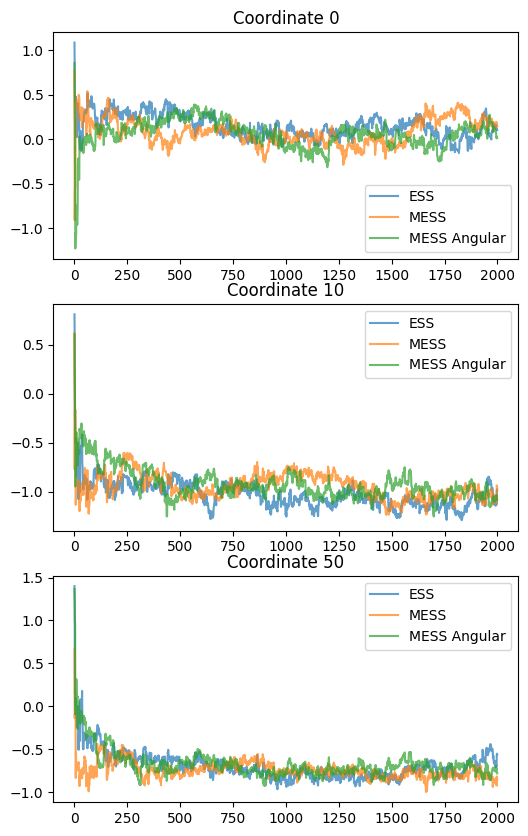

In [149]:
idx = [0, 10, 50]

fig, axes = plt.subplots(len(idx), 1, figsize=(6, 10))
for i, k in enumerate(idx):
    axes[i].plot(chain_ess[0:, k], alpha=0.7, label="ESS")
    axes[i].plot(chain_mess[0:, k], alpha=0.7, label="MESS")
    axes[i].plot(chain_mess_ang[0:, k], alpha=0.7, label="MESS Angular")
    axes[i].set_title(f"Coordinate {k}")
    axes[i].legend()


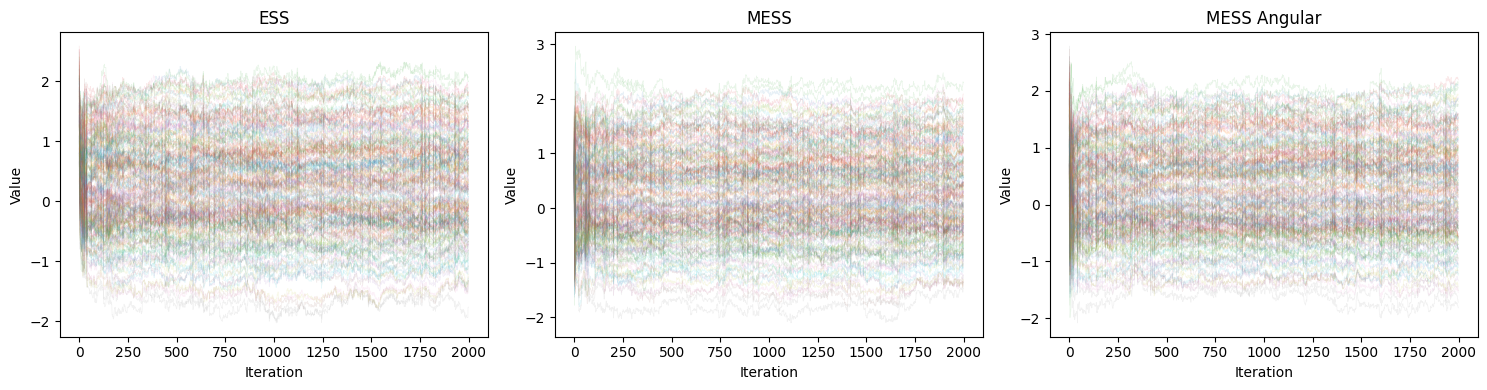

In [150]:
# Traceplot for all coordinates and algorithms at the same time
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

algorithms = [
    ("ESS", chain_ess[0:]),
    ("MESS", chain_mess[0:]),
    ("MESS Angular", chain_mess_ang[0:])
]

for idx, (algo_name, chain) in enumerate(algorithms):
    for k in range(num_data):
        axes[idx].plot(chain[:, k], alpha=0.1, linewidth=0.5)
    axes[idx].set_title(algo_name)
    axes[idx].set_xlabel("Iteration")
    axes[idx].set_ylabel("Value")

plt.tight_layout()
plt.show()

In [151]:
f_true = data["f_true"]

samples_ess = chain_ess[burn_in:]
samples_mess = chain_mess[burn_in:]
samples_mess_ang = chain_mess_ang[burn_in:]

mean_ess = samples_ess.mean(axis=0)
mean_mess = samples_mess.mean(axis=0)
mean_mess_ang = samples_mess_ang.mean(axis=0)

std_ess = samples_ess.std(axis=0)
std_mess = samples_mess.std(axis=0)
std_mess_ang = samples_mess_ang.std(axis=0)


Text(0, 0.5, 'f')

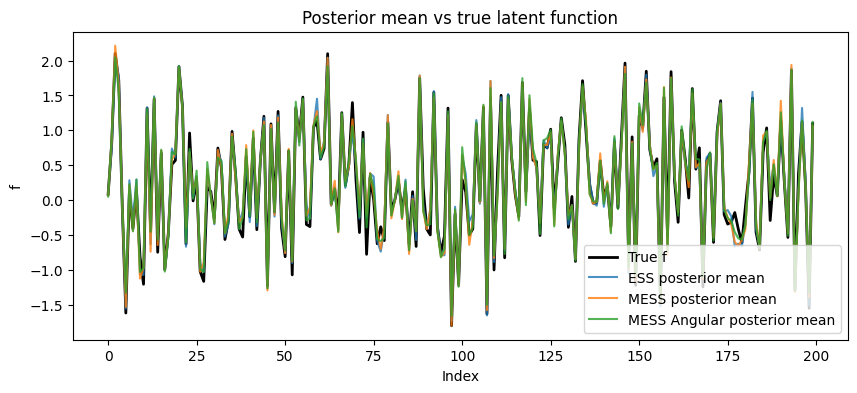

In [152]:
plt.figure(figsize=(10, 4))
plt.plot(f_true, label="True f", color="black", linewidth=2)
plt.plot(mean_ess, label="ESS posterior mean", alpha=0.8)
plt.plot(mean_mess, label="MESS posterior mean", alpha=0.8)
plt.plot(mean_mess_ang, label="MESS Angular posterior mean", alpha=0.8)
plt.legend()
plt.title("Posterior mean vs true latent function")
plt.xlabel("Index")
plt.ylabel("f")


Text(0.5, 1.0, 'Posterior mean error')

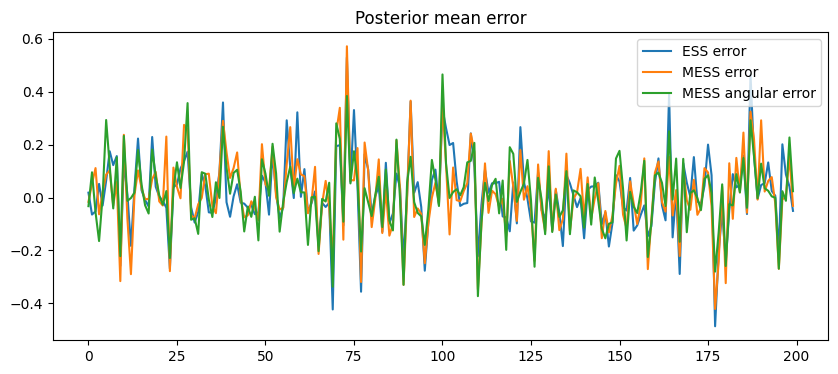

In [153]:
err_ess = mean_ess - f_true
err_mess = mean_mess - f_true
err_mess_ang = mean_mess_ang - f_true

plt.figure(figsize=(10, 4))
plt.plot(err_ess, label="ESS error")
plt.plot(err_mess, label="MESS error")
plt.plot(err_mess_ang, label="MESS angular error")
plt.legend()
plt.title("Posterior mean error")


In [154]:
rmse_ess = np.sqrt(np.mean(err_ess**2))
rmse_mess = np.sqrt(np.mean(err_mess**2))
rmse_mess_ang = np.sqrt(np.mean(err_mess_ang**2))

print("RMSE ESS :", rmse_ess)
print("RMSE MESS:", rmse_mess)
print("RMSE MESS angular:", rmse_mess_ang)


RMSE ESS : 0.14223954639421613
RMSE MESS: 0.1455925043919776
RMSE MESS angular: 0.1307849213606044


Text(0.5, 1.0, 'Standardized posterior error')

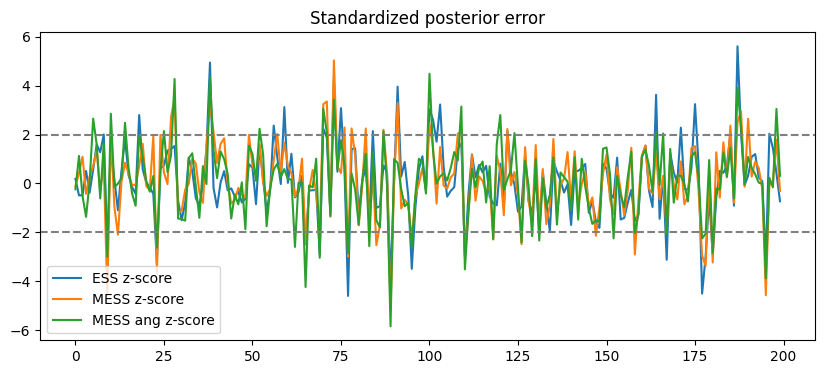

In [155]:
z_ess = (mean_ess - f_true) / std_ess
z_mess = (mean_mess - f_true) / std_mess
z_mess_ang = (mean_mess_ang - f_true) / std_mess_ang

plt.figure(figsize=(10, 4))
plt.plot(z_ess, label="ESS z-score")
plt.plot(z_mess, label="MESS z-score")
plt.plot(z_mess_ang, label="MESS ang z-score")
plt.axhline(2, color="gray", linestyle="--")
plt.axhline(-2, color="gray", linestyle="--")
plt.legend()
plt.title("Standardized posterior error")


In [156]:
# ESS
lower_ess = np.percentile(samples_ess, 2.5, axis=0)
upper_ess = np.percentile(samples_ess, 97.5, axis=0)

coverage_ess = np.mean(
    (f_true >= lower_ess) & (f_true <= upper_ess)
)

print("ESS 95% coverage:", coverage_ess)

# MESS
lower_mess = np.percentile(samples_mess, 2.5, axis=0)
upper_mess = np.percentile(samples_mess, 97.5, axis=0)
coverage_mess = np.mean(
    (f_true >= lower_mess) & (f_true <= upper_mess)
)   
print("MESS 95% coverage:", coverage_mess)

# MESS angular
lower_mess = np.percentile(samples_mess_ang, 2.5, axis=0)
upper_mess = np.percentile(samples_mess_ang, 97.5, axis=0)
coverage_mess_ang = np.mean(
    (f_true >= lower_mess) & (f_true <= upper_mess)
)   
print("MESS 95% coverage:", coverage_mess_ang)

ESS 95% coverage: 0.82
MESS 95% coverage: 0.775
MESS 95% coverage: 0.79


Text(0.5, 1.0, 'Posterior mean vs observations')

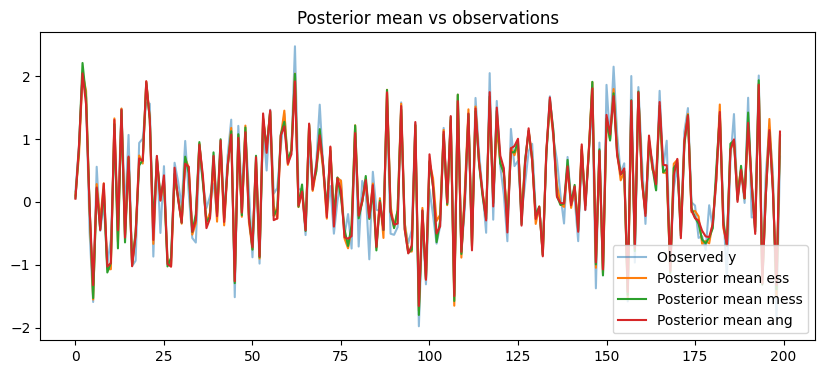

In [157]:
plt.figure(figsize=(10, 4))
plt.plot(y, label="Observed y", alpha=0.5)
plt.plot(mean_ess, label="Posterior mean ess")
plt.plot(mean_mess, label="Posterior mean mess")
plt.plot(mean_mess_ang, label="Posterior mean ang")
plt.legend()
plt.title("Posterior mean vs observations")


In [159]:
# Compute the effective sample size for each method
max_lag = 1200
ess_ess = estimate_effective_sample_size(chain_ess[burn_in:, :], max_lag=max_lag)
ess_mess = estimate_effective_sample_size(chain_mess[burn_in:, :], max_lag=max_lag)
ess_mess_ang = estimate_effective_sample_size(chain_mess_ang[burn_in:, :], max_lag=max_lag)  

# Effective sample size per minute
percentage_useful_samples = (n_iters - burn_in) / n_iters
ess_minute_ess = ess_ess / (percentage_useful_samples * ess_time / 60.0)
ess_minute_mess = ess_mess / (percentage_useful_samples * mess_time / 60.0)
ess_minute_mess_ang = ess_mess_ang / (percentage_useful_samples * mess_ang_time / 60.0)

Estimating ESS for each parameter.
Estimating ESS for each parameter.
Estimating ESS for each parameter.


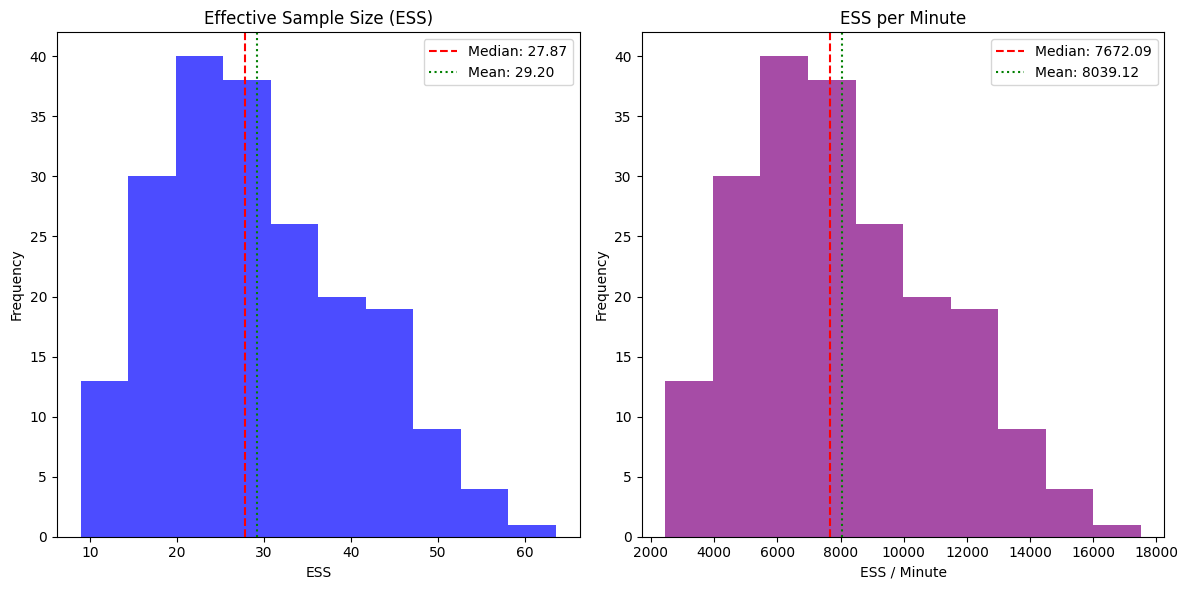

{'mean_ess': np.float64(29.202606227493952),
 'median_ess': np.float64(27.86934314703474),
 'mean_ess_per_minute': np.float64(8039.118218465242),
 'median_ess_per_minute': np.float64(7672.087295381546),
 'min_ess': np.float64(8.92952235369296),
 'max_ess': np.float64(63.57181693452546),
 'min_ess_per_minute': np.float64(2458.1876451897087),
 'max_ess_per_minute': np.float64(17500.539086066972)}

In [160]:
plot_ess_histograms(ess_ess, ess_minute_ess, figsize=(12, 6), 
                       parameter_names=None, bins=10)

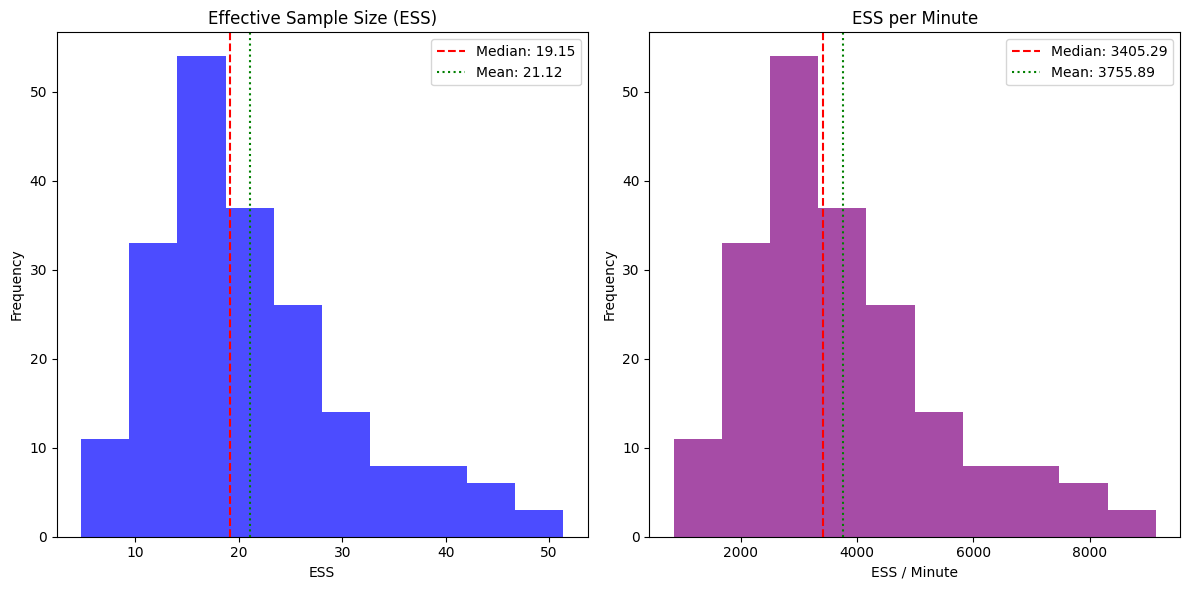

{'mean_ess': np.float64(21.1181188391244),
 'median_ess': np.float64(19.146770796344242),
 'mean_ess_per_minute': np.float64(3755.893946288549),
 'median_ess_per_minute': np.float64(3405.286288650576),
 'min_ess': np.float64(4.734713628107905),
 'max_ess': np.float64(51.392430461749804),
 'min_ess_per_minute': np.float64(842.0770045234627),
 'max_ess_per_minute': np.float64(9140.232609106037)}

In [161]:
plot_ess_histograms(ess_mess, ess_minute_mess, figsize=(12, 6), 
                       parameter_names=None, bins=10)

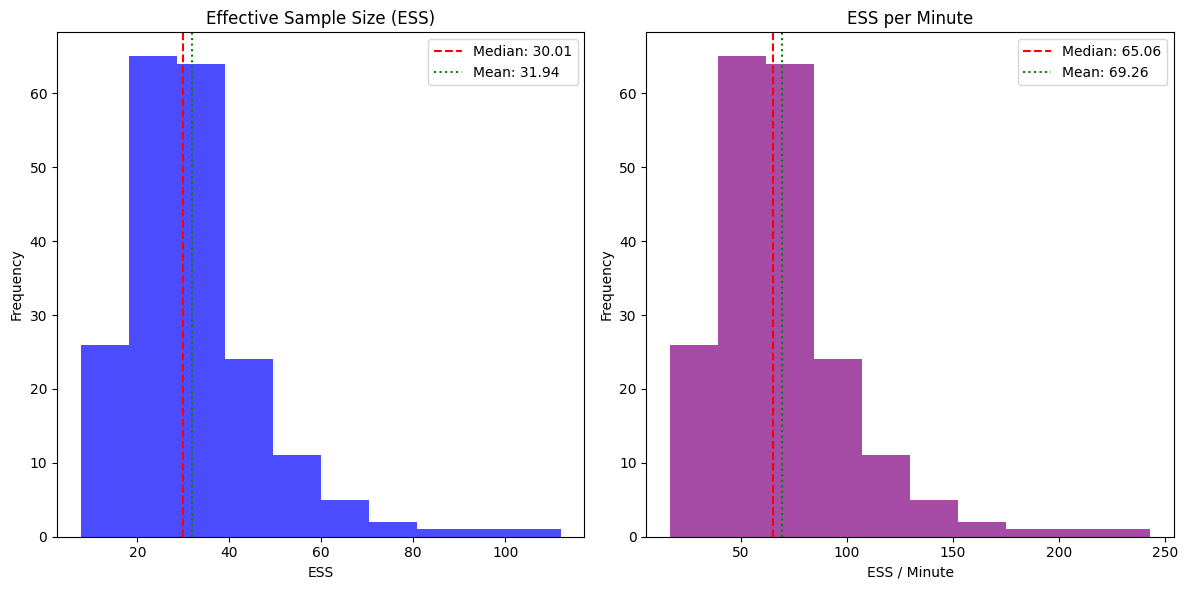

{'mean_ess': np.float64(31.942267308309866),
 'median_ess': np.float64(30.005193501670348),
 'mean_ess_per_minute': np.float64(69.25775914216761),
 'median_ess_per_minute': np.float64(65.05776326066237),
 'min_ess': np.float64(7.73715530930836),
 'max_ess': np.float64(112.01130618023392),
 'min_ess_per_minute': np.float64(16.7758297708008),
 'max_ess_per_minute': np.float64(242.8647907098335)}

In [162]:
plot_ess_histograms(ess_mess_ang, ess_minute_mess_ang, figsize=(12, 6), 
                       parameter_names=None, bins=10)

In [ ]:
#
